# Gradient Boosting from scratch

Tiny version of **Gradient Boosting for regression**.

The idea is simple:

1. Start with a constant prediction.
2. Compute the residual errors.
3. Train a weak learner to predict those residuals.
4. Add the weak learner's prediction to the model.
5. Repeat.

For squared error loss, the residuals correspond to the **negative gradient** of the loss.

We will use very simple **decision stumps** (trees of depth 1) as weak learners.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Create a tiny regression dataset

We generate one-dimensional data so that the behavior of the boosting algorithm is easy to visualize.

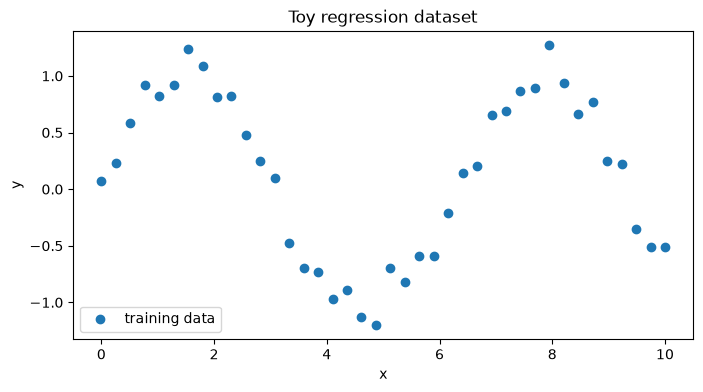

In [2]:
X = np.linspace(0, 10, 40)

# Non-linear target + a little noise
y = np.sin(X) + 0.15 * np.random.randn(len(X))

plt.figure(figsize=(8, 4))
plt.scatter(X, y, label="training data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy regression dataset")
plt.legend()
plt.show()

## 2. Decision stump

A stump makes one split:

$$
x < threshold
$$

and predicts one constant value on the left and another on the right.

During training we test possible thresholds and choose the split that minimizes squared error.

In [3]:
class DecisionStump:
    def __init__(self):
        self.threshold = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y):
        best_loss = float("inf")

        # Possible split positions
        thresholds = (X[:-1] + X[1:]) / 2

        for threshold in thresholds:
            left_mask = X < threshold
            right_mask = ~left_mask

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            left_value = y[left_mask].mean()
            right_value = y[right_mask].mean()

            predictions = np.where(
                left_mask,
                left_value,
                right_value
            )

            loss = np.mean((y - predictions) ** 2)

            if loss < best_loss:
                best_loss = loss
                self.threshold = threshold
                self.left_value = left_value
                self.right_value = right_value

        return self

    def predict(self, X):
        return np.where(
            X < self.threshold,
            self.left_value,
            self.right_value
        )

## 3. Gradient Boosting

For mean squared error:

$$
L = \frac{1}{N}\sum_i (y_i - \hat{y}_i)^2
$$

the direction that reduces the loss is proportional to:

$$
y_i - \hat{y}_i
$$

which is exactly the **residual**.

At every boosting step we train a new stump to predict the current residuals.

In [4]:
class SimpleGradientBoostingRegressor:
    def __init__(self, n_estimators=20, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.initial_prediction = None
        self.stumps = []
        self.training_loss = []

    def fit(self, X, y):
        # Initial model: predict the mean target value
        self.initial_prediction = y.mean()

        current_prediction = np.full_like(
            y,
            self.initial_prediction,
            dtype=float
        )

        for step in range(self.n_estimators):

            # Negative gradient for squared error = residual
            residuals = y - current_prediction

            # Fit weak learner to residuals
            stump = DecisionStump()
            stump.fit(X, residuals)

            # Prediction of the correction
            correction = stump.predict(X)

            # Update ensemble prediction
            current_prediction += self.learning_rate * correction

            # Store weak learner
            self.stumps.append(stump)

            # Track mean squared error
            mse = np.mean((y - current_prediction) ** 2)
            self.training_loss.append(mse)

            print(
                f"Step {step + 1:2d} | "
                f"MSE = {mse:.4f} | "
                f"split = {stump.threshold:.3f}"
            )

        return self

    def predict(self, X):
        prediction = np.full(
            len(X),
            self.initial_prediction,
            dtype=float
        )

        for stump in self.stumps:
            prediction += self.learning_rate * stump.predict(X)

        return prediction

## 4. Train the model

In [5]:
model = SimpleGradientBoostingRegressor(
    n_estimators=30,
    learning_rate=0.2
)

model.fit(X, y)

Step  1 | MSE = 0.4724 | split = 2.692
Step  2 | MSE = 0.4419 | split = 2.949
Step  3 | MSE = 0.4144 | split = 6.282
Step  4 | MSE = 0.3897 | split = 2.692
Step  5 | MSE = 0.3677 | split = 6.538
Step  6 | MSE = 0.3472 | split = 3.205
Step  7 | MSE = 0.3289 | split = 6.282
Step  8 | MSE = 0.3123 | split = 3.205
Step  9 | MSE = 0.2974 | split = 6.282
Step 10 | MSE = 0.2838 | split = 2.436
Step 11 | MSE = 0.2715 | split = 9.359
Step 12 | MSE = 0.2575 | split = 6.795
Step 13 | MSE = 0.2467 | split = 3.205
Step 14 | MSE = 0.2355 | split = 6.282
Step 15 | MSE = 0.2251 | split = 9.359
Step 16 | MSE = 0.2162 | split = 6.795
Step 17 | MSE = 0.2063 | split = 3.205
Step 18 | MSE = 0.1985 | split = 6.026
Step 19 | MSE = 0.1901 | split = 9.359
Step 20 | MSE = 0.1827 | split = 3.205
Step 21 | MSE = 0.1752 | split = 6.026
Step 22 | MSE = 0.1690 | split = 3.205
Step 23 | MSE = 0.1629 | split = 6.795
Step 24 | MSE = 0.1566 | split = 9.359
Step 25 | MSE = 0.1516 | split = 6.026
Step 26 | MSE = 0.1459 | 

## 5. Final prediction

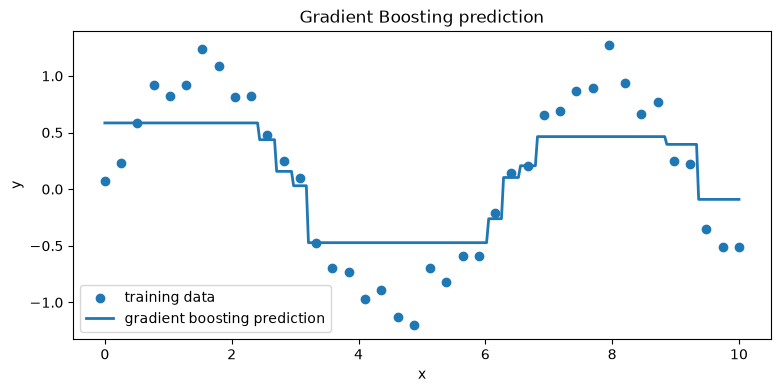

In [6]:
X_test = np.linspace(0, 10, 300)
y_pred = model.predict(X_test)

plt.figure(figsize=(9, 4))
plt.scatter(X, y, label="training data")
plt.plot(X_test, y_pred, linewidth=2, label="gradient boosting prediction")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Boosting prediction")
plt.legend()
plt.show()

## 6. Training loss

As more weak learners are added, the training error should decrease.

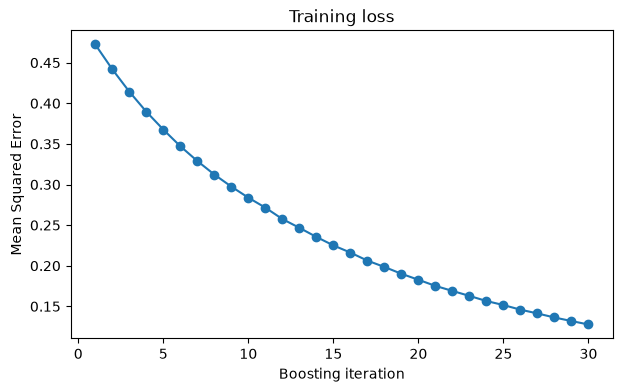

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(
    range(1, len(model.training_loss) + 1),
    model.training_loss,
    marker="o"
)

plt.xlabel("Boosting iteration")
plt.ylabel("Mean Squared Error")
plt.title("Training loss")
plt.show()

## 7. See boosting happen step by step

The function below reconstructs the ensemble after a selected number of boosting stages.

In [8]:
def predict_after_n_stages(model, X, n_stages):
    prediction = np.full(
        len(X),
        model.initial_prediction,
        dtype=float
    )

    for stump in model.stumps[:n_stages]:
        prediction += model.learning_rate * stump.predict(X)

    return prediction

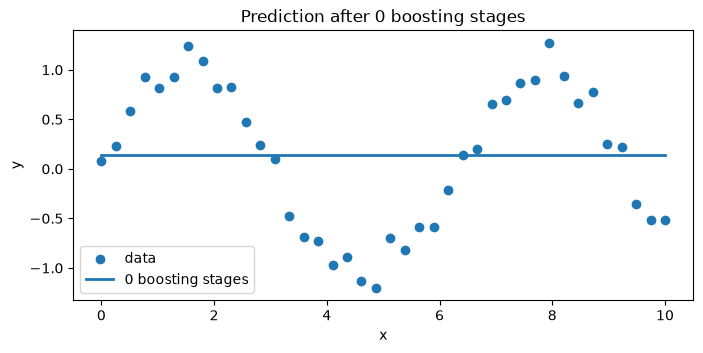

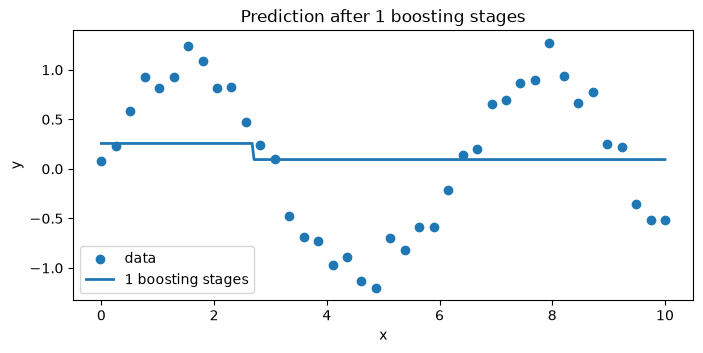

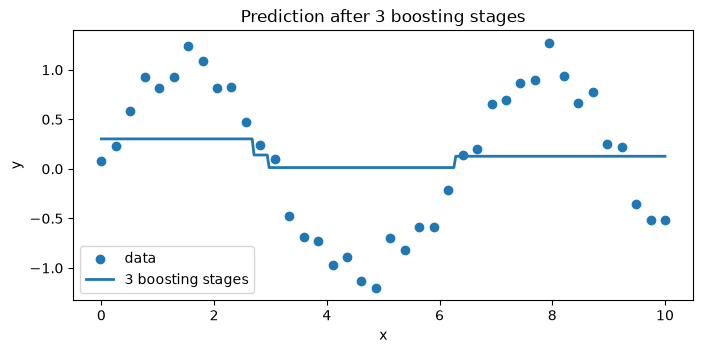

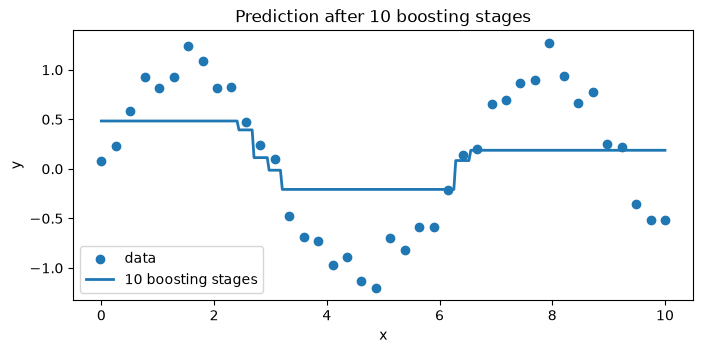

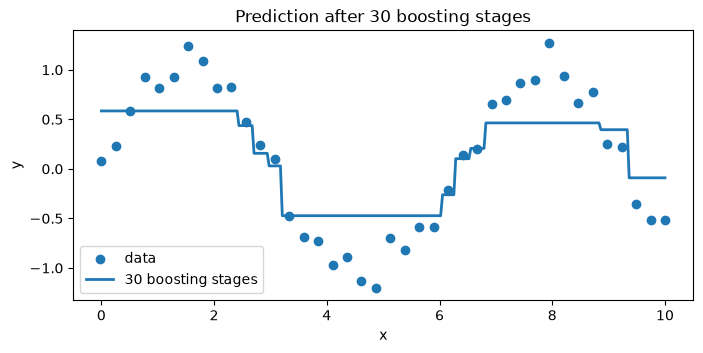

In [9]:
stages = [0, 1, 3, 10, 30]

for n in stages:
    if n == 0:
        y_stage = np.full(
            len(X_test),
            model.initial_prediction
        )
    else:
        y_stage = predict_after_n_stages(model, X_test, n)

    plt.figure(figsize=(8, 3.5))
    plt.scatter(X, y, label="data")
    plt.plot(X_test, y_stage, linewidth=2, label=f"{n} boosting stages")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Prediction after {n} boosting stages")
    plt.legend()
    plt.show()

## 8. What each learner is doing

Each new stump predicts the residual error left by the previous ensemble.

Conceptually:

```text
model_0(x) = mean(y)

residual_1 = y - model_0(x)
model_1(x) = model_0(x) + learning_rate * stump_1(x)

residual_2 = y - model_1(x)
model_2(x) = model_1(x) + learning_rate * stump_2(x)

...
```

So Gradient Boosting builds a strong model **sequentially**, with each learner correcting mistakes made by the learners before it.

## Main formula

The ensemble is:

$$
F_M(x)
=
F_0(x)
+
\eta \sum_{m=1}^{M} h_m(x)
$$

where:

- $F_0(x)$ is the initial constant prediction,
- $h_m(x)$ is weak learner $m$,
- $M$ is the number of boosting stages,
- $\eta$ is the learning rate.

This notebook uses squared error regression because it makes the connection between **gradient descent** and **residual fitting** particularly clear.